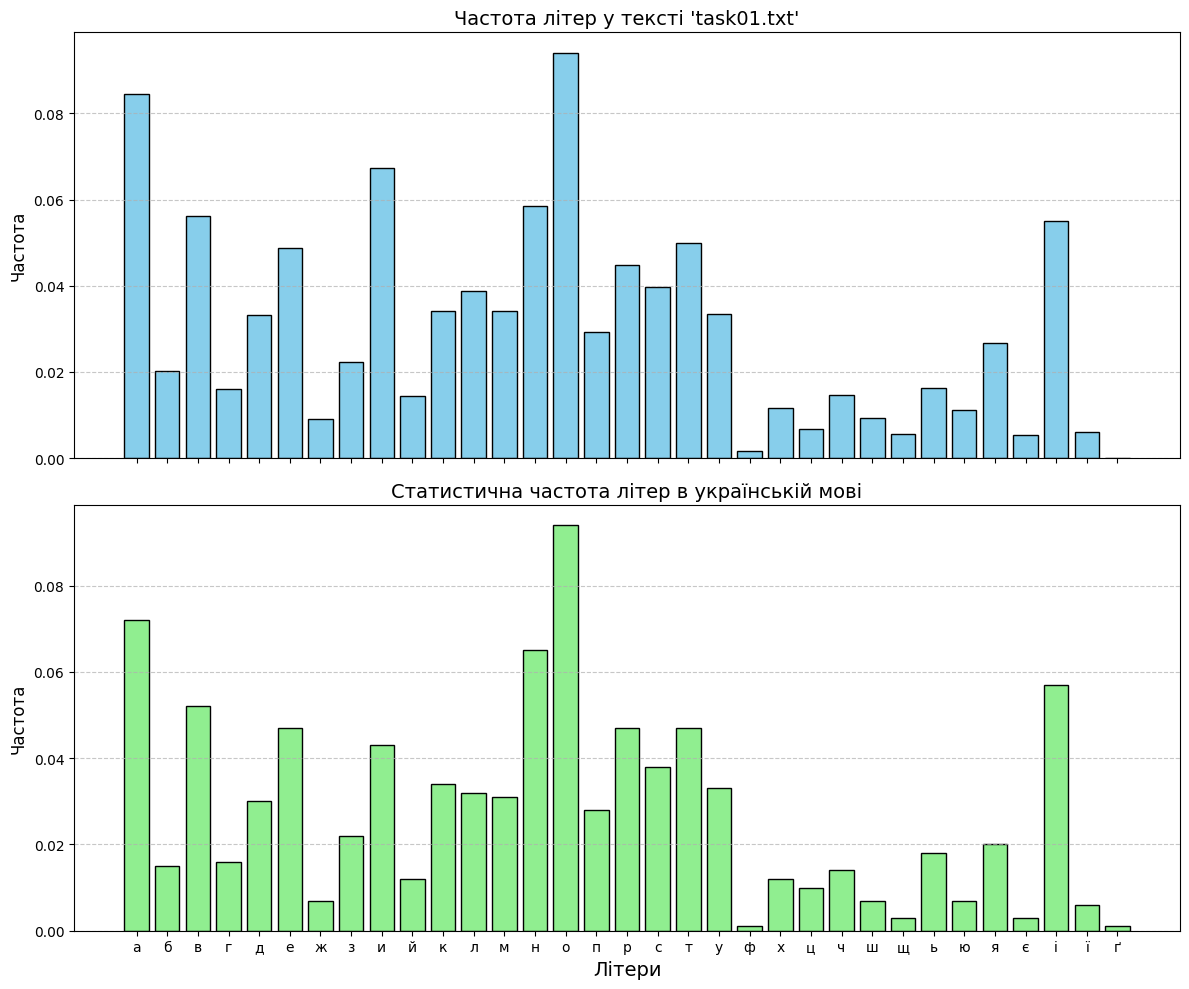

In [7]:
# task 1
import collections
import matplotlib.pyplot as plt

def histogram(filename):
    alphabet = "абвгґдеєжзиіїйклмнопрстуфхцчшщьюя"
    alphabet_sorted = sorted(list(alphabet))
    
    standard_freq = {
        'а': 0.072, 'б': 0.015, 'в': 0.052, 'г': 0.016, 'ґ': 0.001, 'д': 0.030, 
        'е': 0.047, 'є': 0.003, 'ж': 0.007, 'з': 0.022, 'и': 0.043, 'і': 0.057, 
        'ї': 0.006, 'й': 0.012, 'к': 0.034, 'л': 0.032, 'м': 0.031, 'н': 0.065, 
        'о': 0.094, 'п': 0.028, 'р': 0.047, 'с': 0.038, 'т': 0.047, 'у': 0.033, 
        'ф': 0.001, 'х': 0.012, 'ц': 0.010, 'ч': 0.014, 'ш': 0.007, 'щ': 0.003, 
        'ь': 0.018, 'ю': 0.007, 'я': 0.020
    }

    try:
        with open(filename, 'r', encoding='utf-8') as file:
            text = file.read()
            
    except FileNotFoundError:
        print(f"Error: Could not find the file '{filename}'.")
        return

    text = text.lower()
    letters = [char for char in text if char in alphabet]
    total = len(letters)
    
    counts = collections.Counter(letters)
    
    text_freqs = [counts.get(char, 0) / total if total > 0 else 0 for char in alphabet_sorted]
    std_freqs = [standard_freq[char] for char in alphabet_sorted]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    ax1.bar(alphabet_sorted, text_freqs, color='skyblue', edgecolor='black')
    ax1.set_title(f"Частота літер у тексті '{filename}'", fontsize=14)
    ax1.set_ylabel('Частота', fontsize=12)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    
    ax2.bar(alphabet_sorted, std_freqs, color='lightgreen', edgecolor='black')
    ax2.set_title("Статистична частота літер в українській мові", fontsize=14)
    ax2.set_xlabel('Літери', fontsize=14)
    ax2.set_ylabel('Частота', fontsize=12)
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    histogram('task01.txt')

In [8]:
# task 2
def vigenere_encrypt(text, key):
    encrypted_text = ""
    key = key.upper()
    key_index = 0
    
    for char in text:
        if char.isalpha():
            shift = ord(key[key_index % len(key)]) - ord('A')
            
            if char.isupper():
                new_char = chr((ord(char) - ord('A') + shift) % 26 + ord('A'))
            else:
                new_char = chr((ord(char) - ord('a') + shift) % 26 + ord('a'))
                
            encrypted_text += new_char
            key_index += 1
        else:
            encrypted_text += char
            
    return encrypted_text

def vigenere_decrypt(text, key):
    decrypted_text = ""
    key = key.upper()
    key_index = 0
    
    for char in text:
        if char.isalpha():
            shift = ord(key[key_index % len(key)]) - ord('A')
            
            if char.isupper():
                new_char = chr((ord(char) - ord('A') - shift) % 26 + ord('A'))
            else:
                new_char = chr((ord(char) - ord('a') - shift) % 26 + ord('a'))
                
            decrypted_text += new_char
            key_index += 1
        else:
            decrypted_text += char
            
    return decrypted_text

if __name__ == "__main__":
    original_message = "Hello, World! This is a secret message."
    secret_key = "PYTHON"
    
    print("--- Vigenere cipher ---")
    print(f"Plaintext: {original_message}")
    print(f"Key:     {secret_key}\n")
    
    encrypted = vigenere_encrypt(original_message, secret_key)
    print(f"Ciphertext:   {encrypted}")
    
    decrypted = vigenere_decrypt(encrypted, secret_key)
    print(f"Plaintext:  {decrypted}")

--- Vigenere cipher ---
Plaintext: Hello, World! This is a secret message.
Key:     PYTHON

Ciphertext:   Wcesc, Jdpek! Huxq bz o ftaklh ztqlhur.
Plaintext:  Hello, World! This is a secret message.


In [9]:
# task 3

UKR_LOWER = "абвгґдеєжзиіїйклмнопрстуфхцчшщьюя"
UKR_UPPER = "АБВГҐДЕЄЖЗИІЇЙКЛМНОПРСТУФХЦЧШЩЬЮЯ"

def vigenere_encrypt_ua(text, key):
    encrypted_text = ""
    key = [char.lower() for char in key if char.lower() in UKR_LOWER]
    
    key_index = 0
    
    for char in text:
        if char in UKR_LOWER:
            shift = UKR_LOWER.find(key[key_index % len(key)])
            new_idx = (UKR_LOWER.find(char) + shift) % 33
            encrypted_text += UKR_LOWER[new_idx]
            key_index += 1
        elif char in UKR_UPPER:
            shift = UKR_LOWER.find(key[key_index % len(key)])
            new_idx = (UKR_UPPER.find(char) + shift) % 33
            encrypted_text += UKR_UPPER[new_idx]
            key_index += 1
        else:
            encrypted_text += char
            
    return encrypted_text

def vigenere_decrypt_ua(text, key):
    decrypted_text = ""
    key = [char.lower() for char in key if char.lower() in UKR_LOWER]
    
    key_index = 0
    
    for char in text:
        if char in UKR_LOWER:
            shift = UKR_LOWER.find(key[key_index % len(key)])
            new_idx = (UKR_LOWER.find(char) - shift) % 33
            decrypted_text += UKR_LOWER[new_idx]
            key_index += 1
        elif char in UKR_UPPER:
            shift = UKR_LOWER.find(key[key_index % len(key)])
            new_idx = (UKR_UPPER.find(char) - shift) % 33
            decrypted_text += UKR_UPPER[new_idx]
            key_index += 1
        else:
            decrypted_text += char
            
    return decrypted_text

In [14]:
# Standard letter frequencies in the Ukrainian language
STD_FREQ = {
    'а': 0.072, 'б': 0.015, 'в': 0.052, 'г': 0.016, 'ґ': 0.001, 'д': 0.030, 
    'е': 0.047, 'є': 0.003, 'ж': 0.007, 'з': 0.022, 'и': 0.043, 'і': 0.057, 
    'ї': 0.006, 'й': 0.012, 'к': 0.034, 'л': 0.032, 'м': 0.031, 'н': 0.065, 
    'о': 0.094, 'п': 0.028, 'р': 0.047, 'с': 0.038, 'т': 0.047, 'у': 0.033, 
    'ф': 0.001, 'х': 0.012, 'ц': 0.010, 'ч': 0.014, 'ш': 0.007, 'щ': 0.003, 
    'ь': 0.018, 'ю': 0.007, 'я': 0.020
}

def calculate_ic(text):
    N = len(text)
    if N <= 1: 
        return 0
    counts = collections.Counter(text)
    # IC = 33 * Sum(Ni * (Ni - 1)) / (N * (N - 1))
    sum_n = sum(count * (count - 1) for count in counts.values())
    return 33 * sum_n / (N * (N - 1))

def find_key_length(ciphertext, max_len=15):
    """Finds the most probable key length using the Index of Coincidence."""
    clean_text = "".join([c for c in ciphertext.lower() if c in UKR_LOWER])
    
    best_len = 1
    best_ic = 0
    
    print("--- Key Length Analysis (IC) ---")
    for k in range(1, max_len + 1):
        ic_sum = 0
        for i in range(k):
            column = clean_text[i::k]
            ic_sum += calculate_ic(column)
        
        avg_ic = ic_sum / k
        print(f"Length {k:2}: IC = {avg_ic:.3f}")
        
        if avg_ic > best_ic:
            best_ic = avg_ic
            best_len = k
            
    return best_len

def find_key(ciphertext, key_length):
    """Finds the key using the Chi-squared statistic."""
    clean_text = "".join([c for c in ciphertext.lower() if c in UKR_LOWER])
    key = ""
    
    for i in range(key_length):
        column = clean_text[i::key_length]
        best_shift = 0
        min_chi_sq = float('inf')
        
        for shift in range(33):
            decrypted_col = [UKR_LOWER[(UKR_LOWER.find(c) - shift) % 33] for c in column]
            counts = collections.Counter(decrypted_col)
            N = len(decrypted_col)
            
            chi_sq = 0
            for char in UKR_LOWER:
                observed = counts.get(char, 0)
                expected = N * STD_FREQ[char]
                if expected > 0:
                    chi_sq += ((observed - expected) ** 2) / expected
            
            if chi_sq < min_chi_sq:
                min_chi_sq = chi_sq
                best_shift = shift
                
        key += UKR_LOWER[best_shift]
        
    return key

if __name__ == "__main__":
    filename = 'task01.txt'
    with open(filename, 'r', encoding='utf-8') as file:
        original = file.read()
    secret_key = "КЛЮЧ"
    
    print(f"Secret key:    {secret_key}\n")
    
    encrypted = vigenere_encrypt_ua(original, secret_key)
    
    # Cryptanalysis
    guessed_length = find_key_length(encrypted, max_len=8)
    print(f"Most probable key length: {guessed_length}")
    
    guessed_key = find_key(encrypted, guessed_length)
    print(f"Guessed key: '{guessed_key}'\n")
    
    cracked_text = vigenere_decrypt_ua(encrypted, guessed_key)
    with open('task03_decrypted.txt', 'w', encoding='utf-8') as file:
        file.write(cracked_text)

Secret key:    КЛЮЧ

--- Key Length Analysis (IC) ---
Length  1: IC = 1.194
Length  2: IC = 1.335
Length  3: IC = 1.194
Length  4: IC = 1.607
Length  5: IC = 1.194
Length  6: IC = 1.335
Length  7: IC = 1.194
Length  8: IC = 1.607
Most probable key length: 4
Guessed key: 'ключ'

